# Notebook 3: Ewaluacja i analiza wyników

## Detekcja cyberprzemocy (hejtu) w polskich wpisach na Twitterze

W tym notebooku:
1. Porównujemy ilościowo oba podejścia (klasyczne SVM vs Transformer HerBERT) na ostatecznym zbiorze testowym.
2. Przeprowadzamy jakościową analizę błędów.
3. Identyfikujemy typowe pomyłki modeli z konkretnymi przykładami z Twittera.
4. Formułujemy ostateczne wnioski z projektu.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
print("Biblioteki załadowane!")

Biblioteki załadowane!


In [2]:
# Wczytanie predykcji
results_df = pd.read_csv("test_predictions.csv")

with open("results_summary.pkl", "rb") as f:
    summary = pickle.load(f)

TEXT_COL = "tweet"
LABEL_COL = "label"

if "tweet" not in results_df.columns:
    TEXT_COL = "text"

y_true = results_df[LABEL_COL].values
y_pred_classic = results_df["pred_classic"].values
y_pred_transformer = results_df["pred_transformer"].values

print(f"Liczba próbek testowych: {len(results_df)}")
print(f"Podejście klasyczne: {summary['classic_name']}")
print(f"Podejście Transformer: {summary['transformer_name']}")

Liczba próbek testowych: 750
Podejście klasyczne: SVM (LinearSVC)
Podejście Transformer: HerBERT


### 2. Porównanie ilościowe


Porównanie metryk na zbiorze testowym:
                       Accuracy  Precision  Recall  F1-score
Model                                                       
SVM (LinearSVC)          0.9227     0.9044  0.9227    0.8995
HerBERT (Transformer)    0.9333     0.9236  0.9333    0.9251


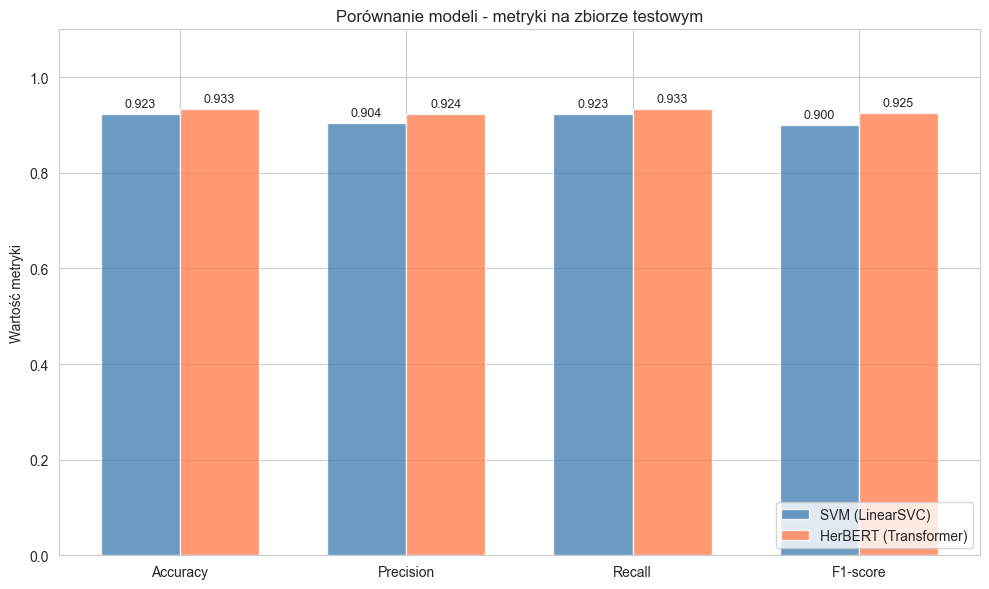

In [3]:
# Tabela porównawcza metryk
metrics_data = []

for name, y_pred in [
    (summary["classic_name"], y_pred_classic),
    ("HerBERT (Transformer)", y_pred_transformer),
]:
    metrics_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1-score": f1_score(y_true, y_pred, average="weighted"),
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_df = metrics_df.set_index("Model")

print("Porównanie metryk na zbiorze testowym:")
print("=" * 60)
print(metrics_df.round(4).to_string())
print("=" * 60)

# Wykres porównawczy metryk
metrics_plot = metrics_df.T

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_plot.index))
width = 0.35

bars1 = ax.bar(
    x - width / 2,
    metrics_plot.iloc[:, 0],
    width,
    label=metrics_plot.columns[0],
    color="steelblue",
    alpha=0.8,
)
bars2 = ax.bar(
    x + width / 2,
    metrics_plot.iloc[:, 1],
    width,
    label=metrics_plot.columns[1],
    color="coral",
    alpha=0.8,
)

ax.set_ylabel("Wartość metryki")
ax.set_title("Porównanie modeli - metryki na zbiorze testowym")
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot.index)
ax.legend(loc="lower right")
ax.set_ylim(0, 1.1)

# Wartości nad słupkami
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

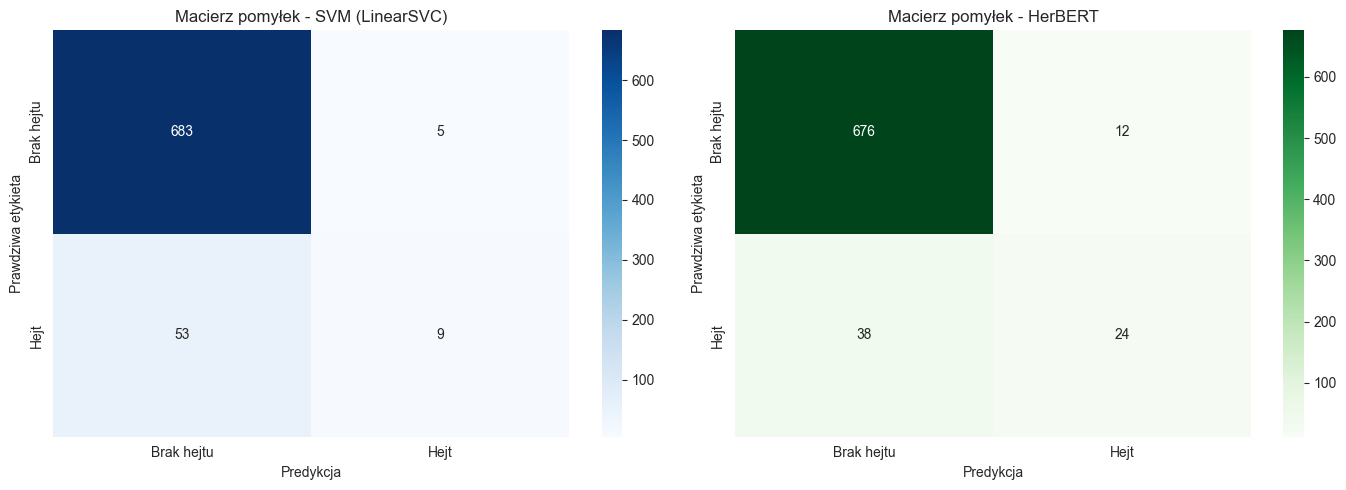

In [4]:
# Macierze pomyłek obok siebie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, y_pred, cmap) in enumerate([
    (summary["classic_name"], y_pred_classic, "Blues"),
    ("HerBERT", y_pred_transformer, "Greens"),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        ax=axes[idx],
        xticklabels=["Brak hejtu", "Hejt"], # Zmienione etykiety
        yticklabels=["Brak hejtu", "Hejt"], # Zmienione etykiety
    )
    axes[idx].set_title(f"Macierz pomyłek - {name}")
    axes[idx].set_xlabel("Predykcja")
    axes[idx].set_ylabel("Prawdziwa etykieta")

plt.tight_layout()
plt.show()

In [6]:
# Szczegółowe raporty klasyfikacji
print(f"{'='*60}")
print(f"Raport klasyfikacji - {summary['classic_name']}")
print(f"{'='*60}")
print(classification_report(
    y_true, y_pred_classic, target_names=["Brak hejtu", "Hejt"]
))

print(f"\n{'='*60}")
print(f"Raport klasyfikacji - HerBERT")
print(f"{'='*60}")
print(classification_report(
    y_true, y_pred_transformer, target_names=["Brak hejtu", "Hejt"]
))

Raport klasyfikacji - SVM (LinearSVC)
              precision    recall  f1-score   support

  Brak hejtu       0.93      0.99      0.96       688
        Hejt       0.64      0.15      0.24        62

    accuracy                           0.92       750
   macro avg       0.79      0.57      0.60       750
weighted avg       0.90      0.92      0.90       750


Raport klasyfikacji - HerBERT
              precision    recall  f1-score   support

  Brak hejtu       0.95      0.98      0.96       688
        Hejt       0.67      0.39      0.49        62

    accuracy                           0.93       750
   macro avg       0.81      0.68      0.73       750
weighted avg       0.92      0.93      0.93       750



### 3.Analiza błędów

Kategorie błędów:
error_type
oba poprawne                678
oba błędne                   36
tylko klasyczny błędny       22
tylko transformer błędny     14
Name: count, dtype: int64

Procent zgodności predykcji obu modeli: 95.20%


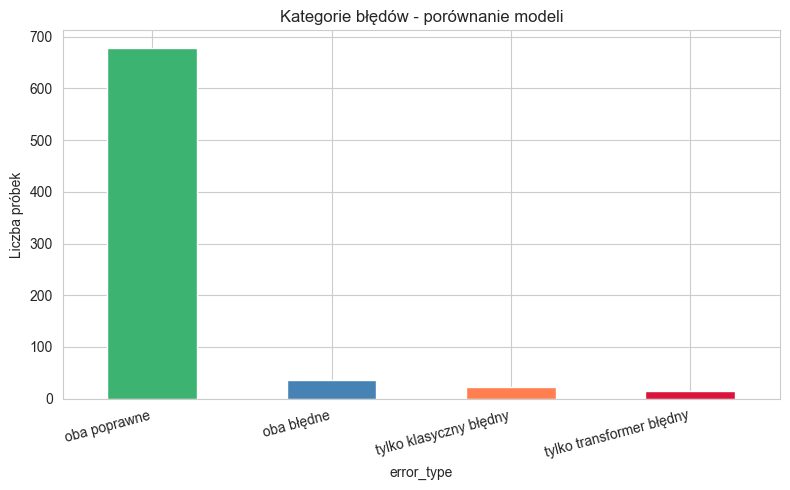

In [7]:
# Identyfikacja błędnych predykcji
results_df["classic_correct"] = (y_true == y_pred_classic)
results_df["transformer_correct"] = (y_true == y_pred_transformer)

# Kategorie błędów
results_df["error_type"] = "oba poprawne"
results_df.loc[
    ~results_df["classic_correct"] & results_df["transformer_correct"],
    "error_type"
] = "tylko klasyczny błędny"
results_df.loc[
    results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "tylko transformer błędny"
results_df.loc[
    ~results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "oba błędne"

print("Kategorie błędów:")
error_counts = results_df["error_type"].value_counts()
print(error_counts)

# Zgodność to sytuacje, gdy oba mają rację LUB oba się mylą tak samo
zgodnosc = (results_df["pred_classic"] == results_df["pred_transformer"]).mean()
print(f"\nProcent zgodności predykcji obu modeli: {zgodnosc:.2%}")

# Wykres kategorii błędów
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["mediumseagreen", "steelblue", "coral", "crimson"]
error_counts.plot(kind="bar", color=colors[:len(error_counts)], ax=ax)
ax.set_title("Kategorie błędów - porównanie modeli")
ax.set_ylabel("Liczba próbek")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [13]:
TEXT_COL = "sentence"
LABEL_COL = "label"

def print_errors(df_subset, title):
    print(title)
    print("=" * 70)
    if len(df_subset) == 0:
        print("Brak przypadków w tej kategorii.\n")
        return

    for _, row in df_subset.iterrows():
        text = str(row[TEXT_COL])[:200]
        true_label = "Hejt" if row[LABEL_COL] == 1 else "Brak hejtu"

        if "klasyczne" in title.lower():
            pred_label = "Hejt" if row["pred_classic"] == 1 else "Brak hejtu"
        else:
            pred_label = "Hejt" if row["pred_transformer"] == 1 else "Brak hejtu"

        print(f"\nTekst: {text}...")
        print(f" Prawda: {true_label} | Predykcja: {pred_label}")
        print("-" * 70)
    print("\n")

# Filtrowanie i wyświetlanie
classic_errors = results_df[~results_df["classic_correct"]].head(5)
print_errors(classic_errors, "PRZYKŁADY BŁĘDNYCH PREDYKCJI - Podejście klasyczne (SVM)")

transformer_errors = results_df[~results_df["transformer_correct"]].head(5)
print_errors(transformer_errors, "PRZYKŁADY BŁĘDNYCH PREDYKCJI - HerBERT (Transformer)")

both_wrong = results_df[results_df["error_type"] == "oba błędne"].head(5)
print_errors(both_wrong, "NAJTRUDNIEJSZE PRZYPADKI - oba modele błędne")

PRZYKŁADY BŁĘDNYCH PREDYKCJI - Podejście klasyczne (SVM)

Tekst: @anonymized_account Jak zwykle genialna @anonymized_account 😁😁. Miłego wypoczynku🥀...
 Prawda: Brak hejtu | Predykcja: Hejt
----------------------------------------------------------------------

Tekst: @anonymized_account @anonymized_account A to potocznie Cię stary idioto Rachoń zaprosił do studia, żebyś znowu pobrudził trochę....
 Prawda: Hejt | Predykcja: Brak hejtu
----------------------------------------------------------------------

Tekst: @anonymized_account Chuj Cię to obchodzi! :)...
 Prawda: Hejt | Predykcja: Brak hejtu
----------------------------------------------------------------------

Tekst: @anonymized_account @anonymized_account Maly murzyn, silny i zdrowy...
 Prawda: Hejt | Predykcja: Brak hejtu
----------------------------------------------------------------------

Tekst: @anonymized_account @anonymized_account Ty pajacu, zmień sobie herb na pusty łeb....
 Prawda: Hejt | Predykcja: Brak hejtu
-------

Accuracy wg długości tekstu (słowa):
            classic_acc  transformer_acc  count
length_bin                                     
1-10             0.9281           0.9346    306
11-25            0.9186           0.9321    442
26-50            1.0000           1.0000      2
51-100              NaN              NaN      0
100+                NaN              NaN      0


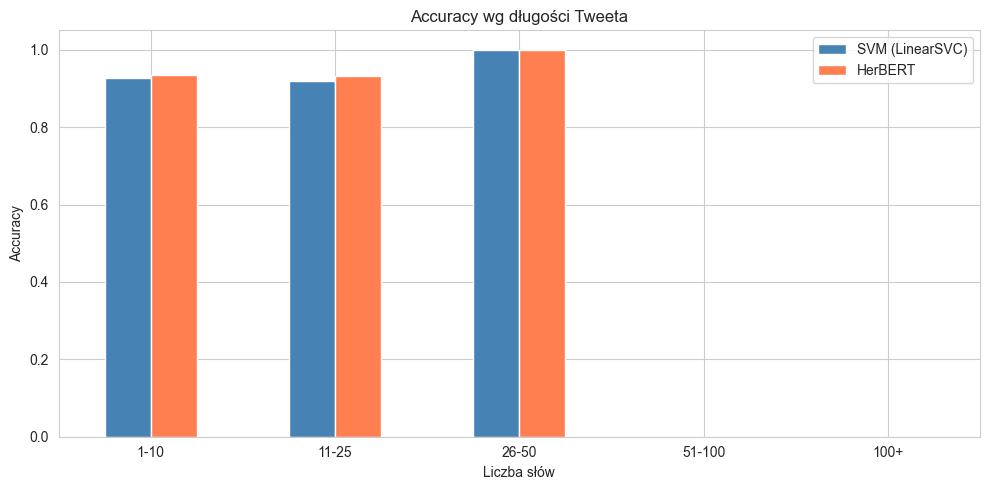

In [14]:
# Analiza błędów wg długości tekstu
results_df["word_count_calc"] = results_df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

# Binowanie długości
bins = [0, 10, 25, 50, 100, float("inf")]
labels = ["1-10", "11-25", "26-50", "51-100", "100+"]
results_df["length_bin"] = pd.cut(results_df["word_count_calc"], bins=bins, labels=labels)

# Accuracy per bin
acc_by_length = results_df.groupby("length_bin", observed=False).agg(
    classic_acc=("classic_correct", "mean"),
    transformer_acc=("transformer_correct", "mean"),
    count=("classic_correct", "count"),
).round(4)

print("Accuracy wg długości tekstu (słowa):")
print(acc_by_length.to_string())

# Wykres
fig, ax = plt.subplots(figsize=(10, 5))
acc_by_length[["classic_acc", "transformer_acc"]].plot(
    kind="bar", ax=ax, color=["steelblue", "coral"]
)
ax.set_title("Accuracy wg długości Tweeta")
ax.set_xlabel("Liczba słów")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.legend([summary["classic_name"], "HerBERT"])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 4. Porównanie jakościowe


In [17]:
print("PRZEWAGA TRANSFORMERA - poprawny Transformer, błędny klasyczny (SVM)")
print("=" * 70)

transformer_wins = results_df[
    results_df["error_type"] == "tylko klasyczny błędny"
].head(3)

if len(transformer_wins) > 0:
    for _, row in transformer_wins.iterrows():
        text = str(row[TEXT_COL])[:250]
        true_label = "Hejt" if row[LABEL_COL] == 1 else "Brak hejtu"
        pred_t = "Hejt" if row["pred_transformer"] == 1 else "Brak hejtu"
        pred_c = "Hejt" if row["pred_classic"] == 1 else "Brak hejtu"

        print(f"\nTekst: {text}...")
        print(f" Prawda: {true_label} | HerBERT: {pred_t} | SVM: {pred_c}")
        print("-" * 70)
else:
    print("Brak przypadków w tej kategorii.")


print(f"\n\nPRZEWAGA KLASYCZNEGO - poprawny klasyczny (SVM), błędny Transformer")
print("=" * 70)

classic_wins = results_df[
    results_df["error_type"] == "tylko transformer błędny"
].head(3)

if len(classic_wins) > 0:
    for _, row in classic_wins.iterrows():
        text = str(row[TEXT_COL])[:250]
        true_label = "Hejt" if row[LABEL_COL] == 1 else "Brak hejtu"
        pred_t = "Hejt" if row["pred_transformer"] == 1 else "Brak hejtu"
        pred_c = "Hejt" if row["pred_classic"] == 1 else "Brak hejtu"

        print(f"\nTekst: {text}...")
        print(f" Prawda: {true_label} | SVM: {pred_c} | HerBERT: {pred_t}")
        print("-" * 70)
else:
    print("Brak przypadków w tej kategorii.")

PRZEWAGA TRANSFORMERA - poprawny Transformer, błędny klasyczny (SVM)

Tekst: @anonymized_account Jak zwykle genialna @anonymized_account 😁😁. Miłego wypoczynku🥀...
 Prawda: Brak hejtu | HerBERT: Brak hejtu | SVM: Hejt
----------------------------------------------------------------------

Tekst: @anonymized_account @anonymized_account A to potocznie Cię stary idioto Rachoń zaprosił do studia, żebyś znowu pobrudził trochę....
 Prawda: Hejt | HerBERT: Hejt | SVM: Brak hejtu
----------------------------------------------------------------------

Tekst: @anonymized_account @anonymized_account Ty pajacu, zmień sobie herb na pusty łeb....
 Prawda: Hejt | HerBERT: Hejt | SVM: Brak hejtu
----------------------------------------------------------------------


PRZEWAGA KLASYCZNEGO - poprawny klasyczny (SVM), błędny Transformer

Tekst: Biała księga czy biala propaganda, paranoicy psychopaci księga, reszta propaganda...
 Prawda: Brak hejtu | SVM: Brak hejtu | HerBERT: Hejt
------------------------

### Podsumowanie wyników

In [18]:
print("\n" + "=" * 60)
print("PODSUMOWANIE PROJEKTU")
print("=" * 60)
print(f"\nZadanie: Detekcja cyberprzemocy (hejtu) w polskich tweetach")
print(f"Zbiór danych: Wpisy z Twittera (Cyberbullying Detection)")
print(f"Próbki testowe: {len(results_df)}")

print(f"\n{'Model':<35} {'Accuracy':>10} {'F1-score':>10}")
print("-" * 58)


acc_c = accuracy_score(y_true, y_pred_classic)
f1_c = f1_score(y_true, y_pred_classic, average="weighted")

acc_t = accuracy_score(y_true, y_pred_transformer)
f1_t = f1_score(y_true, y_pred_transformer, average="weighted")

print(f"{summary['classic_name']:<35} {acc_c:>10.4f} {f1_c:>10.4f}")
print(f"{'HerBERT (Transformer)':<35} {acc_t:>10.4f} {f1_t:>10.4f}")
print("-" * 58)

diff_acc = acc_t - acc_c
diff_f1 = f1_t - f1_c
print(f"{'Różnica (HerBERT - Klasyczny)':<35} {diff_acc:>10.4f} {diff_f1:>10.4f}")


PODSUMOWANIE PROJEKTU

Zadanie: Detekcja cyberprzemocy (hejtu) w polskich tweetach
Zbiór danych: Wpisy z Twittera (Cyberbullying Detection)
Próbki testowe: 750

Model                                 Accuracy   F1-score
----------------------------------------------------------
SVM (LinearSVC)                         0.9227     0.8995
HerBERT (Transformer)                   0.9333     0.9251
----------------------------------------------------------
Różnica (HerBERT - Klasyczny)           0.0107     0.0256


## Wnioski końcowe

### Porównanie podejść

**Podejście klasyczne (TF-IDF + SVM):**
* Szybki trening i inferencja
* Nie wymaga akceleracji GPU
* Dobrze radzi sobie z tweetami zawierającymi wyraźne, bezpośrednie wulgaryzmy
* Ogromne problemy z ironią, sarkazmem i słowami wieloznacznymi

**Podejście Transformer (HerBERT):**
* Lepsze rozumienie kontekstu i niuansów językowych (np. odróżnienie wulgarnej opinii politycznej od bezpośredniego hejtu)
* Wymaga GPU i znacznie więcej pamięci
* Dłuższy czas treningu
* Znacznie lepsze wyniki na trudnych i niejednoznacznych przypadkach cyberprzemocy

### Typowe błędy modeli na analizowanym zbiorze

* **Zakamuflowany sentyment:** Agresywne teksty kończone pozytywnymi emotikonami (np. `:)`, `😁`), które mylą algorytmy.
* **Ironia i sarkazm:** Wpisy, które na pierwszy rzut oka wyglądają na pochwałę, a w rzeczywistości są atakiem.
* **Brak szerszego kontekstu:** Krótkie tweety będące odpowiedzią w dłuższym wątku, gdzie bez znajomości poprzednich wiadomości trudno ocenić intencje autora.
* **Słownictwo potoczne i wulgaryzmy-przerywniki:** Mylenie ogólnej frustracji (np. narzekania na prawo) z celowym, wymierzonym w kogoś hejtem.

### Możliwe ulepszenia

* Więcej epok treningu dla Transformera (fine-tuning)
* Augmentacja danych (np. sztuczne generowanie trudnych przykładów z ironią)
* Dostarczenie algorytmom historii dyskusji (analiza całych wątków z Twittera, a nie pojedynczych zdań)
* Użycie większego modelu (np. Polish RoBERTa)